In [2]:
from cyecca.dubins import derive_dubins, plot_dubins_path
import casadi as ca
plan, eval_fn = derive_dubins()
p0, psi0 = ca.DM([0, 0]), 0.0  # Start position and heading
p1, psi1 = ca.DM([10, 10]), 3*ca.pi/2  # End position and heading
R = 4.0  # Turn radius
cost, type, a1, d, a2, tp0, tp1, c0, c1 = plan(p0, psi0, p1, psi1, R)
s = 0.5  # Evaluation point along path (0 to 1)
x, y, psi = eval_fn(s, p0, psi0, a1, d, a2, tp0, tp1, c0, c1, R)



float(cost) > 0  # Path cost should be positive

True

Trying to plot a path from 0,0 facing east to 10, 10 facing north:

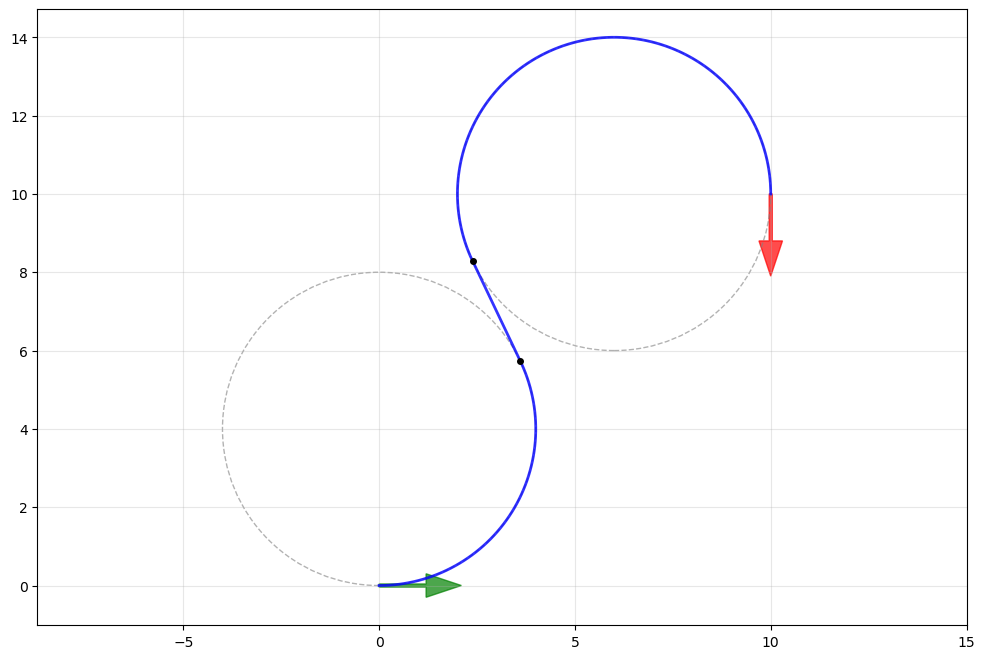

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Convert CasADi objects to numpy arrays/floats for matplotlib compatibility
p0_np = np.array(p0).flatten()
p1_np = np.array(p1).flatten()
psi0_float = float(psi0)
psi1_float = float(psi1)
R_float = float(R)

# plot dubins path
fig, ax = plt.subplots(figsize=(12, 8))
ax, path_data = plot_dubins_path(p0_np, psi0_float, p1_np, psi1_float, R_float, plan, eval_fn, ax=ax)
plt.show()

In [ ]:
import sympy

deriv = 3 # jerk
poly_deg = 5 # degree of polynomial
n_legs = 10

k, l, m, n, n_c, n_l = sympy.symbols('k, l, m, n, n_c, n_l', integer=True)
# k summation dummy variable
# n deg of polynomial
# 

beta = sympy.symbols('beta')  # scaled time on leg, 0-1
c = sympy.MatrixSymbol('c', n_c, 1)  # coefficient matrices, length is n+1, must be variable (n_c)
T = sympy.symbols('T')  # time of leg
P = sympy.summation(c[k, 0]*sympy.factorial(k)/sympy.factorial(k-m)*beta**(k-m)/T**m, (k, m, n))  # polynomial derivative
print("P:")
display(P)
P = P.subs({m: deriv, n: poly_deg}).doit()
print("P evaluated with m: deriv and n: poly_deg :")
display(P)
J = sympy.integrate(P**2, (beta, 0, 1))#.doit()  # cost
print("J:")
display(J)
J = J.doit()
print("J.doit():")
p = sympy.Matrix([c[i, 0] for i in range(poly_deg+1)])  # vector of terms
#display(p)
Q = sympy.Matrix([J]).jacobian(p).jacobian(p)/2  # find Q using second derivative
#display(Q)
assert (p.T@Q@p)[0, 0].expand() == J  # assert hessian matches cost
print('pTQp vs J')
display(p.T@Q@p)
display(J)

Ti = sympy.MatrixSymbol('T', n_l, 1)
display(sympy.diag(*[ Q.subs(T, Ti[i]) for i in range(n_legs) ]))



Sum(beta**(k - m)*factorial(k)*c[k, 0]/(T**m*factorial(k - m)), (k, m, n))

(60*beta**2*c[5, 0] + 24*beta*c[4, 0] + 6*c[3, 0])/T**3

J:


36*c[3, 0]**2/T**6 + 144*c[3, 0]*c[4, 0]/T**6 + 240*c[3, 0]*c[5, 0]/T**6 + 192*c[4, 0]**2/T**6 + 720*c[4, 0]*c[5, 0]/T**6 + 720*c[5, 0]**2/T**6

pTQp vs J


Matrix([[(36*c[3, 0]/T**6 + 72*c[4, 0]/T**6 + 120*c[5, 0]/T**6)*c[3, 0] + (72*c[3, 0]/T**6 + 192*c[4, 0]/T**6 + 360*c[5, 0]/T**6)*c[4, 0] + (120*c[3, 0]/T**6 + 360*c[4, 0]/T**6 + 720*c[5, 0]/T**6)*c[5, 0]]])

36*c[3, 0]**2/T**6 + 144*c[3, 0]*c[4, 0]/T**6 + 240*c[3, 0]*c[5, 0]/T**6 + 192*c[4, 0]**2/T**6 + 720*c[4, 0]*c[5, 0]/T**6 + 720*c[5, 0]**2/T**6

Matrix([
[0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0],
[0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,              0,              0,              0, 0, 0, 0,           